# **Gender Pronouns Solution Notebook Pt.2**<br>

## **1.** OpenSub Dataset Upload

In [1]:
import sys, re, pickle, copy
import pandas as pd
from collections import Counter
sys.path.append('../modules')

In [2]:
with open("../local_data/model_reference/first_person_f.pkl", 'rb') as f:
    df_female = pickle.load(f)

with open("../local_data/model_reference/first_person_m.pkl", 'rb') as f:
    df_male = pickle.load(f)

with open("../local_data/model_reference/first_person_na.pkl", 'rb') as f:
    df_first_person = pickle.load(f)

with open("../local_data/model_reference/opensub_2mil_sample.pkl", 'rb') as f:
    df_text = pickle.load(f)

## **2.** Helper Functions

In [3]:
def extract_sample(df_main, mask_2nd, name_df):
    print(f"[{name_df}]: {(mask_2nd.sum()/len(df_main)*100):.2f}% of examples extracted")
    df_mask = df_main[mask_2nd].reset_index(drop=True)
    return df_mask, df_main[~mask_2nd].reset_index(drop=True)

def search(snt, re_pattern):
    return bool(re.search(re_pattern, snt, re.IGNORECASE))

def apply_mask(df, re_pattern, col='pol_text'):
    return df[col].apply(lambda snt: search(snt, re_pattern))

## **3.** Second-Person Sentence Filter

In [4]:
re_2ndperson = r"\b(?:you['’](?:re|ve|ll|d)|you|your|yours|yourself|thou|thee|thy|thine|thyself)\b"

mask_2nd_person = df_text['eng_text'].str.contains(re_2ndperson, case=False, na=False, regex=True)
mask_2nd_person_1st_na = df_first_person['eng_text'].str.contains(re_2ndperson, case=False, na=False, regex=True)
mask_2nd_person_1st_m = df_male['eng_text'].str.contains(re_2ndperson, case=False, na=False, regex=True)
mask_2nd_person_1st_f = df_female['eng_text'].str.contains(re_2ndperson, case=False, na=False, regex=True)

print(f"Num examples >>\n[df_text]:{mask_2nd_person.sum():>17}\n[df_first_person]:   {mask_2nd_person_1st_na.sum()}\n\
[df_male]: {mask_2nd_person_1st_m.sum():>16}\n[df_female]: {mask_2nd_person_1st_f.sum():>14}")

Num examples >>
[df_text]:           592097
[df_first_person]:   207500
[df_male]:            44684
[df_female]:          19324


In [5]:
df_2nd_person, df_text = extract_sample(df_text, mask_2nd_person, 'df_text')
df_2nd_person_na, df_first_person = extract_sample(df_first_person, mask_2nd_person_1st_na, 'df_first_person')
df_2nd_person_m, df_male = extract_sample(df_male, mask_2nd_person_1st_m, 'df_male')
df_2nd_person_f, df_female = extract_sample(df_female, mask_2nd_person_1st_f, 'df_female')

[df_text]: 25.21% of examples extracted
[df_first_person]: 30.48% of examples extracted
[df_male]: 27.69% of examples extracted
[df_female]: 28.15% of examples extracted


In [6]:
df_2nd_person_f['self_ref'] = 'F'
df_2nd_person_m['self_ref'] = 'M'
df_2nd_person_na['self_ref'] = 'NA'
df_2nd_person['self_ref'] = 'NA_OTHER'

df_2nd_person = pd.concat([df_2nd_person, df_2nd_person_m, df_2nd_person_f, df_2nd_person_na], ignore_index=True)

## **4.** Second-Person Pronouns Extraction

In [7]:
df_proc_f = pd.DataFrame(columns=df_2nd_person.columns)
df_proc_m = pd.DataFrame(columns=df_2nd_person.columns)
df_proc_p = pd.DataFrame(columns=df_2nd_person.columns)

### **GROUP 0**: First-Person Sentences Final Classification

In [8]:
edge_pat_m = r"\b((od|wy|u|\b)dzia|(m|b|skrz)yd|(ob|\b)strza|(syg|kardy|ka)na|(admi|gene)ra|(po|u)mys|[tp]y|(m|tyt)u|(an|kośc)io|\
anio|diab|(ma|o|krze)s|dzie|peda|zespo|kryszta|świat|(gar|źró|sio)d|(ko|\b)z|zapa|(mater|c)ia|(kow|zwierci|popych)ad|(\b|apo)sto|(proto|\b)ko)łem\b"

mask_refs = (df_2nd_person['self_ref'] != 'M') & (df_2nd_person['self_ref'] != 'F')

edge_case_m = apply_mask(df_2nd_person, edge_pat_m)
mask_m = (apply_mask(df_2nd_person, r"\b\w+(łem|[łl]bym)\b") & mask_refs) & ~edge_case_m

edge_case_f = apply_mask(df_2nd_person, r"\b([wzk]|(po|wy|prze)sy|(za|od|po|wy)wo|dzia|po|zdo)łam\b")
mask_f = (apply_mask(df_2nd_person, r"\b\w+(łam|[łl]abym)\b") & mask_refs) & ~edge_case_f

print(f"Num edge cases --> [Female]: {edge_case_f.sum()} | [Male]: {edge_case_m.sum()}")
print(f"Num examples --> [Female]: {mask_f.sum()} | [Male]: {mask_m.sum()}")

df_2nd_person.loc[mask_m, 'self_ref'] = 'M'
df_2nd_person.loc[mask_f, 'self_ref'] = 'F'

Num edge cases --> [Female]: 229 | [Male]: 704
Num examples --> [Female]: 640 | [Male]: 2180


### **GROUP 1A**: Past tense 2nd person (-aś / -eś / -ście)

In [9]:
def extract_pronouns(df_main, df_proc_f, df_proc_m, df_proc_p, mask_f, mask_m, mask_p):
    df_proc_f = pd.concat([df_proc_f, df_main[mask_f]], ignore_index=True)
    df_proc_m = pd.concat([df_proc_m, df_main[mask_m]], ignore_index=True)
    
    if df_proc_p is not None:
        df_proc_p = pd.concat([df_proc_p, df_main[mask_p]], ignore_index=True)
        df_main = df_main[~(mask_f | mask_m | mask_p)].reset_index(drop=True)
        return df_main, df_proc_f, df_proc_m, df_proc_p
    else:
        df_main = df_main[~(mask_f | mask_m)].reset_index(drop=True)
        return df_main, df_proc_f, df_proc_m

In [10]:
edge_case_m = apply_mask(df_2nd_person, r"\b((prz[ye]|(p|\b)od|[zn]a|\b|w[yz]|[zwu]|roz|po)[nw]i|\w*(gdzi|jaki|[żr])|[ia]l|jest|czyj)eś\b")
edge_case_f = apply_mask(df_2nd_person, r"\b(.|\w*g|chyb|któr|ad)aś\b") | apply_mask(df_2nd_person, r"\bjakaś\b(?!.*\bty\b)")
edge_case_p = apply_mask(df_2nd_person, r"\b([mgt]o|(w|z|pod)ej|(jede|osiem|czter|kilka)na|(\b|nie)szczę|(o|rze)czywi|gu|gu\
                                        |(wy|do|u)j|(c|m|dw)ie|(zaje|oso)bi|gu|gu|li|oszu|nare|zem|uroczy|(kon|\b)tek)ście\b")

mask_m = apply_mask(df_2nd_person, r"\b\w+eś\b") & ~edge_case_m
mask_f = apply_mask(df_2nd_person, r"\b\w+aś\b") & ~edge_case_f
mask_p = apply_mask(df_2nd_person, r"\b\w+ście\b") & ~edge_case_p

print(f"Num edge cases --> [Female]: {edge_case_f.sum()} | [Male]: {edge_case_m.sum()} | [Plural]: {edge_case_p.sum()}")
print(f"Num examples --> [Female]: {mask_f.sum()} | [Male]: {mask_m.sum()} | [Plural]: {mask_p.sum()}")

df_2nd_person, df_proc_f, df_proc_m, df_proc_p = extract_pronouns(df_2nd_person, df_proc_f, df_proc_m, df_proc_p, mask_f, mask_m, mask_p)

Num edge cases --> [Female]: 368 | [Male]: 42259 | [Plural]: 4815
Num examples --> [Female]: 21970 | [Male]: 56651 | [Plural]: 12912


### **GROUP 1B**: Past tense 2nd person **( -łabyś / -łbyś / -byście )**

In [11]:
mask_m = apply_mask(df_2nd_person, r"\b\w+[łl]by[śs]\b")
mask_f = apply_mask(df_2nd_person, r"\b\w+[łl]aby[śs]\b")
mask_p = apply_mask(df_2nd_person, r"\b\w*by[śs]cie\b")
print(f"Num examples --> [Female]: {mask_f.sum()} | [Male]: {mask_m.sum()} | [Plural]: {mask_p.sum()} (Previously extracted)")
df_2nd_person, df_proc_f, df_proc_m, df_proc_p = extract_pronouns(df_2nd_person, df_proc_f, df_proc_m, df_proc_p, mask_f, mask_m, mask_p)

Num examples --> [Female]: 1998 | [Male]: 5511 | [Plural]: 35 (Previously extracted)


### **GROUP 2A**: Formal address **( pan / pani / pa-{nie/nowie} )**

In [12]:
edge_case_m = apply_mask(df_2nd_person, r"\b((tw|m)ój|[wn]asz|on|(\b|tam)ten)\b\s+\bpan\b")
edge_case_f = apply_mask(df_2nd_person, r"\b((tw|m)oj|[wn]asz|on|(\b|tam)t)a\b\s+\bpani\b")

mask_m = apply_mask(df_2nd_person, r"\bpan\b") & ~edge_case_m
mask_f = apply_mask(df_2nd_person, r"\bpani\b") & ~edge_case_f

mask_p = apply_mask(df_2nd_person, r"\bladies\b", 'eng_text') & apply_mask(df_2nd_person, r"\bpanie\b")
mask_p = mask_p | apply_mask(df_2nd_person, r"\b((tw|m)oje|drogie)\b\s+\bpanie\b") | apply_mask(df_2nd_person, r"\bpanowie\b")

print(f"Num edge cases --> [Female]: {edge_case_f.sum()} | [Male]: {edge_case_m.sum()}")
print(f"Num examples --> [Female]: {mask_f.sum()} | [Male]: {mask_m.sum()} | [Plural]: {mask_p.sum()}")
df_2nd_person, df_proc_f, df_proc_m, df_proc_p = extract_pronouns(df_2nd_person, df_proc_f, df_proc_m, df_proc_p, mask_f, mask_m, mask_p)

Num edge cases --> [Female]: 125 | [Male]: 109
Num examples --> [Female]: 23130 | [Male]: 52673 | [Plural]: 1444


### **GROUP 2B**: Formal address **( pana / panią / pa-{niom/nom} )**

In [13]:
edge_case_m = apply_mask(df_2nd_person, r"\b((tw|m)ojego|[wn]aszego|go|(\b|tam)tego)\b\s+\bpana\b")
edge_case_f = apply_mask(df_2nd_person, r"\b((jest m|tw)oj|(tam|\b)t|wasz)ą\b\s+\bpanią\b")
edge_case_p = apply_mask(df_2nd_person, r"\b((tw|m)oim|[wn]aszym|im|(\b|tam)tym)\b\s+\bpa(ni|n)om\b")

mask_m = apply_mask(df_2nd_person, r"\bpana\b") & ~edge_case_m
mask_f = apply_mask(df_2nd_person, r"\bpanią\b") & ~edge_case_f
mask_p = apply_mask(df_2nd_person, r"\bpa(ni|n)om\b") & ~edge_case_p

print(f"Num edge cases --> [Female]: {edge_case_f.sum()} | [Male]: {edge_case_m.sum()}    | [Plural]: {edge_case_p.sum()}")
print(f"Num examples --> [Female]: {mask_f.sum()} | [Male]: {mask_m.sum()} | [Plural]: {mask_p.sum()}")
df_2nd_person, df_proc_f, df_proc_m, df_proc_p = extract_pronouns(df_2nd_person, df_proc_f, df_proc_m, df_proc_p, mask_f, mask_m, mask_p)

Num edge cases --> [Female]: 18 | [Male]: 53    | [Plural]: 2
Num examples --> [Female]: 2160 | [Male]: 10500 | [Plural]: 134


### **GROUP 2C**: Formal address **( [panu/panem/mężczyzno] / kobieto )**

In [14]:
edge_case_m1 = apply_mask(df_2nd_person, r"\b((tw|m)ojemu|[wn]aszemu|mu|(\b|tam)temu)\b\s+\bpanu\b")
edge_case_m2 = apply_mask(df_2nd_person, r"\b(((kiedy(ś|\b)|nikt|z\b).+)moim|twoim|waszym|tym|jest)\b\s+\bpanem\b")

mask_m = (apply_mask(df_2nd_person, r"\bpanu\b") & ~edge_case_m1) | (apply_mask(df_2nd_person, r"\bpanem\b") & ~edge_case_m2)
mask_m = mask_m | apply_mask(df_2nd_person, r"\bmężczyzno\b")
mask_f = apply_mask(df_2nd_person, r"\bkobieto\b")

print(f"Num examples --> [Female]: {mask_f.sum()} | [Male]: {mask_m.sum()}")

df_2nd_person, df_proc_f, df_proc_m = extract_pronouns(df_2nd_person, df_proc_f, df_proc_m, None, mask_f, mask_m, None)

Num examples --> [Female]: 121 | [Male]: 7470


### **GROUP 3A**: Plural-focused extraction - **leftover verbs**

In [15]:
def extract_single(df_main, df_proc_x, mask_x):
    df_proc_x = pd.concat([df_proc_x, df_main[mask_x]], ignore_index=True)
    df_main = df_main[~(mask_x)].reset_index(drop=True)
    return df_main, df_proc_x

In [16]:
mask_p = apply_mask(df_2nd_person, r"\b((((sprób|zaplan)ow|[gb]r|d|napis)a|(m|widz)ie|(rob|pros|ustaw)i|by)li|jeste|zgło|powinni)[śs]cie\b")
print(f"Num examples --> [Plural]: {mask_p.sum()}")
df_2nd_person, df_proc_p = extract_single(df_2nd_person, df_proc_p, mask_p)

Num examples --> [Plural]: 154


### **GROUP 3B**: Plural-focused extraction - **verbs ending in the suffix -cie**

In [17]:
verbs_cie = df_2nd_person['pol_text'].str.extract(r"\b(\w+cie)\b", flags=re.IGNORECASE)[0].str.lower().value_counts()
verbs_cie = list(verbs_cie.to_dict())
print(f"verbs_cie length: {len(verbs_cie)}")
print(verbs_cie[:13])

verbs_cie length: 3549
['macie', 'życie', 'możecie', 'chcecie', 'wiecie', 'oczywiście', 'będziecie', 'musicie', 'robicie', 'szczęście', 'świecie', 'myślicie', 'widzicie']


In [18]:
verbs_cie = df_2nd_person['pol_text'].str.extract(r"\b(\w+cie)\b", flags=re.IGNORECASE)[0].str.lower().value_counts()
verbs_cie = list(verbs_cie.to_dict())
print(f"verbs_cie length: {len(verbs_cie)}")
print(verbs_cie[:13])

verbs_cie length: 3549
['macie', 'życie', 'możecie', 'chcecie', 'wiecie', 'oczywiście', 'będziecie', 'musicie', 'robicie', 'szczęście', 'świecie', 'myślicie', 'widzicie']


In [19]:
kickout_re = r"\b(\w+([śkłęąuro]|([eoiu]|[^t]a)n)|\w*(([^ż]|\b)r[^azw]|(?<![csr]z)(?<![^\b]ż)y|k.[^jżrpzbi]))cie\b"
print(f"Num removed: {sum(bool(re.search(kickout_re, x)) for x in verbs_cie)}")
verbs_cie = [x for x in verbs_cie if not bool(re.search(kickout_re, x))]
print(f"verbs_cie length: {len(verbs_cie)}")

Num removed: 461
verbs_cie length: 3088


In [20]:
kickout_words = ['bracie', 'tacie', 'wariacie', 'gacie', 'opacie', 'piracie', 'herbacie', 'warsztacie', 'piracie', 'wypłacie',
                 'krawacie', 'stracie', 'aparacie', 'kamracie', 'postacie', 'internacie', 'konfiskacie', 'sekretariacie',
                 'etacie', 'miracie', 'konfederacie', 'kwadracie', 'piłacie', 'celibacie', 'utracie', 'plakacie', 'temacie',
                 'automacie', 'senacie', 'antykwariacie', 'bicie', 'picie', 'całkowicie', 'świcie', 'niesamowicie', 'odbicie',
                 'orbicie', 'mianowicie', 'suficie', 'sowicie', 'pobicie', 'obficie', 'rozkwicie', 'satelicie', 'dynamicie',
                 'wicie', 'upicie', 'kokpicie', 'świecie', 'powiecie', 'wszechświecie', 'kwiecie', 'swiecie', 'zwiecie', 'trzecie',
                 'wrzechświecie', 'zowiecie', 'gadżecie', 'duecie', 'kobiecie', 'planecie', 'gabinecie', 'facecie', 'przecie',
                 'uniwersytecie', 'diecie', 'toalecie', 'zdjecie', 'flecie', 'kwiecie', 'komplecie', 'grzbiecie', 'hamlecie', 'pistolecie',
                 'supermarkecie', 'lecie', 'kadecie', 'rupiecie', 'balecie', 'elżbiecie', 'mecie', 'kennecie', 'chevrolecie',
                 'tybecie', 'zajecie', 'przyjecie', 'gaecie', 'plecie', 'stulecie', 'gazecie', 'gaecie', 'nadużycie', 'przeżycie',
                 'pasożycie', 'szczycie', 'użycie', 'szycie', 'wreszcie', 'nareszcie', 'areszcie', 'ruszcie', 'poczcie', 'chrzcie',
                 'budapeszcie', 'maszcie', 'kapcie', 'egipcie', 'jachcie', 'sierżańcie', 'wachcie', 'labiryncie', 'knechcie',
                 'zgnicie', 'kojocie', 'żakiecie', 'lucie', 'albecie', 'kabriolecie', 'czacie', 'zbicie', 'adepcie', 'poecie',
                 'babcie', 'parapecie', 'hipolicie', 'monecie', 'gorsecie', 'zmiecie', 'pojecie', 'smakowicie', 'pulpicie', 'carlotcie', 
                 'oświacie', 'willacie', 'jelicie', 'griffithcie', 'meczecie', 'bacie', 'marynacie', 'dopicie', 'pospolicie',
                 'sabecie', 'emmecie', 'bufecie', 'majestacie', 'gettcie', 'armacie', 'bilecie', 'oplecie', 'aromacie', 'odwecie',
                 'zowiecie', 'akapicie', 'watcie']
print('Num removed:',  sum(bool(re.search(rf"\b({'|'.join(kickout_words)})\b", x)) for x in verbs_cie))
verbs_cie = [x for x in verbs_cie if not bool(re.search(rf"\b({'|'.join(kickout_words)})\b", x))]

Num removed: 147


In [21]:
mask_p_1 = apply_mask(df_2nd_person, r"\b\w+cie\b")
mask_p_2 = apply_mask(df_2nd_person[mask_p_1], rf"\b({'|'.join(verbs_cie)})\b")
mask_p = (mask_p_1 & mask_p_2)

print(f"Num examples --> [Plural]: {mask_p.sum()}")
df_2nd_person, df_proc_p = extract_single(df_2nd_person, df_proc_p, mask_p)

Num examples --> [Plural]: 30375


### **GROUP 3C**: Plural-focused extraction  **-was / -wasz** etc.

In [22]:
edge_case_p = apply_mask(df_2nd_person, r"\bwaszej\b\s+\bwysoko[śs]ci\b") | apply_mask(df_2nd_person, r"\bwasza\b\s+\bwysoko[śs][ćc]\b")
edge_case_p = edge_case_p | apply_mask(df_2nd_person, r"\bwasza\b\s+\bŁaskawo[śs][ćc]\b")

mask_p = apply_mask(df_2nd_person, r"\b(wa[sm](\b|i)|wasz(\b|[aeąyę]|emu|ej|ych|ym|ego|ymi))\b") & ~edge_case_p

print(f"Num examples --> [Plural]: {mask_p.sum()} | Num edge cases --> [Plural]: {edge_case_p.sum()}")
df_2nd_person, df_proc_p = extract_single(df_2nd_person, df_proc_p, mask_p)

Num examples --> [Plural]: 18650 | Num edge cases --> [Plural]: 1354


In [23]:
mask_p = apply_mask(df_2nd_person, r"\bwy\b")
print(f"Num examples --> [Plural]: {mask_p.sum()}")
df_2nd_person, df_proc_p = extract_single(df_2nd_person, df_proc_p, mask_p)

Num examples --> [Plural]: 1211


### **GROUP 4**: Jesteś - Manual Profession/Noun Conversion

- #### **1.** -arzem --> -arką  **( e.g. lekarzem-lekarką | pisarzem-pisarką )**

In [24]:
def get_female_nouns(df_main, nouns_dict, suffixes_dct):
    nouns_pattern = r'|'.join(re.escape(key) for key in nouns_dict.keys())
    mask_nouns = apply_mask(df_main, rf'\bjesteś\b.+\b({nouns_pattern})\b') & ~apply_mask(df_main, r'\bjestem\b')
    print(f"Num examples: {mask_nouns.sum()}")
    female_nouns = df_main[mask_nouns].reset_index(drop=True)
    dct_comb = nouns_dict | suffixes_dct
    pattern_comb = r'|'.join(re.escape(key) for key in dct_comb.keys())
    female_nouns['pol_text'] = female_nouns['pol_text'].apply(lambda snt: re.sub(pattern_comb, 
                                                                                 lambda match: dct_comb[match.group(0).lower()], 
                                                                                 snt, flags=re.IGNORECASE))
    return female_nouns, mask_nouns

In [25]:
nouns_male = df_2nd_person['pol_text'].str.extract(r'\bjesteś\b.+\b(\w+arzem)\b', flags=re.IGNORECASE)[0].str.lower().value_counts()
nouns_male = nouns_male[nouns_male >= 3].to_dict()
print(nouns_male)

{'lekarzem': 84, 'szczęściarzem': 48, 'pisarzem': 25, 'gliniarzem': 11, 'kucharzem': 10, 'malarzem': 7, 'żeglarzem': 7, 'kanciarzem': 7, 'dziennikarzem': 7, 'nudziarzem': 7, 'marynarzem': 6, 'gospodarzem': 6, 'łgarzem': 6, 'spryciarzem': 5, 'sekretarzem': 5, 'handlarzem': 5, 'cesarzem': 4, 'stolarzem': 4, 'ochroniarzem': 3, 'komisarzem': 3, 'piosenkarzem': 3}


In [26]:
suffix_conversion = {'dobrym': 'dobrą', 'kim': 'ką', 'ym': 'ą', 'łeś': 'łaś', 'kiem': 'czką', 'moim': 'moją', 'tary': 'tara', 
                     'durniu': 'idiotko', 'głupcem': 'idiotką', 'czem': 'czką', 'rem': 'rką', 'tanem': 'tanką', 'grafem': 'grafką'}
nouns_1a = ['lekarzem', 'pisarzem', 'dziennikarzem', 'kucharzem', 'sekretarzem', 'malarzem', 'ochroniarzem', 'marynarzem',
            'handlarzem', 'żeglarzem', 'piosenkarzem']
nouns_1a = {m_noun: re.sub(r"rzem\b", "rką", m_noun) for m_noun in nouns_1a}
female_nouns_1a, mask_nouns_1a = get_female_nouns(df_2nd_person, nouns_1a, suffix_conversion)
print(f"{'='*60}\nfemale_nouns_1a sample:\n\n{female_nouns_1a['pol_text'].sample(3)}\n{'='*60}")

Num examples: 159
female_nouns_1a sample:

1       Czy też jesteś malarką?
66              Jesteś pisarką?
128    Czyż nie jesteś lekarką?
Name: pol_text, dtype: object


In [27]:
nouns_1b = {'szczęściarzem': 'szczęściarą', 'gospodarzem': 'gospodynią', 'nudziarzem': 'nudziarą', 'spryciarzem': 'spryciarą',
            'komisarzem': 'panią komisarz'}
female_nouns_1b, mask_nouns_1b = get_female_nouns(df_2nd_person, nouns_1b, suffix_conversion)
print(f"{'='*60}\nfemale_nouns_1b sample:\n\n{female_nouns_1b['pol_text'].sample(3)}\n{'='*60}")

Num examples: 68
female_nouns_1b sample:

50      Jesteś szczęściarą, Billy.
36    Czyż nie jesteś szczęściarą?
1              Jesteś szczęściarą.
Name: pol_text, dtype: object


In [28]:
df_proc_f = pd.concat([df_proc_f, female_nouns_1a, female_nouns_1b], ignore_index=True)
df_proc_m = pd.concat([df_proc_m, df_2nd_person[mask_nouns_1b | mask_nouns_1a]], ignore_index=True)
df_2nd_person = df_2nd_person[~(mask_nouns_1b | mask_nouns_1a)].reset_index(drop=True)

- #### **2.** -mistrzem --> -mistrzynią **( e.g. [bur]mistrzem - [bur]mistrzynią )**

In [29]:
nouns_male = df_2nd_person['pol_text'].str.extract(r'\bjesteś\b.+\b(\w*mistrzem)\b', flags=re.IGNORECASE)[0].str.lower().value_counts()
nouns_male = nouns_male[nouns_male >= 3].to_dict()
print(nouns_male)

{'mistrzem': 34, 'burmistrzem': 7}


In [30]:
nouns_2 = {'mistrzem': 'mistrzynią', 'burmistrzem': 'burmistrzynią'}
suffix_conversion = {'kim': 'ką', 'ym': 'ą', 'nikiem': 'nicą', 'moim': 'moją', 'rem': 'rką', 'nem': 'nką', 'jakiego': 'jaką',
                     'grany': 'grana'}
female_nouns_2, mask_nouns_2 = get_female_nouns(df_2nd_person, nouns_2, suffix_conversion)
print(f"{'='*60}\nfemale_nouns_2 sample:\n\n{female_nouns_2['pol_text'].sample(3)}\n{'='*60}")

Num examples: 41
female_nouns_2 sample:

9             Ale w jedną jesteś mistrzynią:
0     Hilarius, jesteś prawdziwą mistrzynią!
19                Prince, jesteś mistrzynią.
Name: pol_text, dtype: object


In [31]:
df_proc_f = pd.concat([df_proc_f, female_nouns_2], ignore_index=True)
df_proc_m = pd.concat([df_proc_m, df_2nd_person[mask_nouns_2]], ignore_index=True)
df_2nd_person = df_2nd_person[~(mask_nouns_2)].reset_index(drop=True)

- #### **3.** -nikiem --> -niczką/cą **(e.g. ochotnikiem -> ochotniczką | nieudacznikiem -> nieudacznicą)**

In [32]:
nouns_male = df_2nd_person['pol_text'].str.extract(r'\bjesteś\b.+\b(\w+ikiem)\b', flags=re.IGNORECASE)[0].str.lower().value_counts()
nouns_male = nouns_male[nouns_male >= 3].to_dict()
print(nouns_male)

{'prawnikiem': 24, 'anglikiem': 17, 'katolikiem': 17, 'niewolnikiem': 15, 'strażnikiem': 13, 'magikiem': 10, 'wojownikiem': 9, 'dłużnikiem': 7, 'przeciwnikiem': 7, 'przemytnikiem': 7, 'kierownikiem': 7, 'wspólnikiem': 6, 'pułkownikiem': 6, 'rolnikiem': 6, 'rzeźnikiem': 5, 'zwolennikiem': 5, 'śmiertelnikiem': 5, 'nieudacznikiem': 5, 'miłośnikiem': 5, 'komikiem': 5, 'zawodnikiem': 5, 'ogrodnikiem': 5, 'pracownikiem': 5, 'przewodnikiem': 4, 'urzędnikiem': 4, 'zakładnikiem': 4, 'szkodnikiem': 4, 'mechanikiem': 4, 'grzesznikiem': 3, 'alkoholikiem': 3, 'lotnikiem': 3}


In [33]:
nouns_3b = ['niewolnikiem', 'anglikiem', 'pracownikiem', 'grzesznikiem', 'nieudacznikiem', 'robotnikiem']
nouns_3a = [k for k in nouns_male.keys() if k not in nouns_3b+['pułkownikiem', 'szkodnikiem']]

nouns_3b = {k: re.sub(r"nikiem\b|likiem\b", lambda x: {'nikiem': 'nicą', 'likiem': 'ielką'}[x.group(0)], k) for k in nouns_3b}
nouns_3a = {k: re.sub(r"ikiem\b", 'iczką', k) for k in nouns_3a}

In [34]:
suffix_conversion = {'nim': 'nią', 'ym': 'ą', 'moim': 'moją', 'wielkim': 'wielką', 'jakimś': 'jakąś', 'takim': 'taką',
                     'tem': 'tką', 'łeś': 'łaś', 'jakiego': 'jaką', 'szny': 'szna'}
female_nouns_3, mask_nouns_3 = get_female_nouns(df_2nd_person, nouns_3a | nouns_3b, suffix_conversion)
print(f"{'='*60}\nfemale_nouns_3 sample:\n\n{female_nouns_3['pol_text'].sample(3)}\n{'='*60}")

Num examples: 215
female_nouns_3 sample:

10              Ty jesteś strażniczką.
161    jesteś zwolenniczką anarchizmu?
99          Jesteś katoliczką, prawda?
Name: pol_text, dtype: object


In [35]:
df_proc_f = pd.concat([df_proc_f, female_nouns_3], ignore_index=True)
df_proc_m = pd.concat([df_proc_m, df_2nd_person[mask_nouns_3]], ignore_index=True)
df_2nd_person = df_2nd_person[~(mask_nouns_3)].reset_index(drop=True)

- #### **4.** Final **-em** Noun Conversion

In [36]:
nouns_male = df_2nd_person['pol_text'].str.extract(r'\bjesteś\b.+\b(\w+em)\b', flags=re.IGNORECASE)[0].str.lower().value_counts()
nouns_male = list(nouns_male[nouns_male >= 5].to_dict())
print(nouns_male)

['człowiekiem', 'przyjacielem', 'głupcem', 'synem', 'dzieckiem', 'facetem', 'tchórzem', 'chłopcem', 'ojcem', 'całkiem', 'gościem', 'szefem', 'bratem', 'geniuszem', 'jestem', 'ekspertem', 'królem', 'złodziejem', 'więźniem', 'aniołem', 'kumplem', 'szpiegiem', 'bohaterem', 'oszustem', 'mężem', 'żołnierzem', 'członkiem', 'potworem', 'oficerem', 'typem', 'draniem', 'dupkiem', 'spotkałem', 'świadkiem', 'widziałem', 'duchem', 'dżentelmenem', 'bogiem', 'trupem', 'policjantem', 'detektywem', 'amerykaninem', 'aktorem', 'agentem', 'wrogiem', 'zwierzęciem', 'doktorem', 'księdzem', 'naukowcem', 'myślałem', 'żydem', 'właścicielem', 'kapitanem', 'kretynem', 'pilotem', 'chłopakiem', 'księciem', 'świrem', 'wariatem', 'życiem', 'wiem', 'szeryfem', 'nauczycielem', 'gejem', 'powrotem', 'graczem', 'strzelcem', 'łajdakiem', 'psem', 'diabłem', 'przypadkiem', 'miałem', 'wyjątkiem', 'szaleńcem', 'tancerzem', 'kochankiem', 'twardzielem', 'partnerem', 'durniem', 'uczniem', 'śmieciem', 'głupkiem', 'razem', 'pedał

In [37]:
nouns_4a = [
    'aktorem', 'doktorem', 'dyrektorem', 'amatorem', 'obserwatorem', 'autorem', 'reporterem', 'menadżerem', 'partnerem', 'farmerem',
    'reżyserem', 'uciekinierem', 'frajerem', 'bohaterem', 'klientem', 'ekspertem', 'agentem', 'studentem', 'asystentem', 'pacjentem', 'palantem',
    'policjantem', 'amerykaninem', 'chrześcijaninem', 'indianinem', 'rosjaninem', 'fanem', 'łajdakiem', 'krytykiem', 'członkiem', 'nauczycielem',
    'właścicielem', 'złodziejem', 'czarodziejem', 'naukowcem', 'wariatem', 'piratem', 'fotografem', 'włamywaczem', 'psychologiem'
]
nouns_conversion_4a = {'orem': 'orką', 'erem': 'erką', 'entem': 'entką', 'antem': 'antką', 'aninem': 'anką', 'anem': 'anką',
                       'akiem': 'aczką', 'ykiem': 'yczką', 'kiem': 'kinią', 'cielem': 'cielką', 'ejem': 'ejką',
                       'owcem': 'owczynią','atem': 'atką', 'fem': 'fką', 'aczem': 'aczką', 'ogiem': 'ożką', 'rtem': 'rtką'}

nouns_4a = {k: re.sub(rf"{r'|'.join(nouns_conversion_4a)}", lambda x: nouns_conversion_4a[x.group(0)], k) for k in nouns_4a}

In [38]:
nouns_4b = [
    'przyjacielem', 'szefem', 'więźniem', 'obywatelem', 'kapitanem', 'detektywem', 'żydem', 'oszustem', 'geniuszem', 'adwokatem',
    'kumplem', 'uczniem', 'francuzem', 'tancerzem', 'kochankiem', 'opiekunem', 'niemcem', 'diabłem', 'włochem', 'wybrańcem'
]

nouns_conversion_4b = {'cielem': 'ciółką', 'telem': 'telką', 'plem': 'pelką', 'fem': 'fową', 'źniem': 'źniarką', 'czniem': 'czennicą', 'nem': 'nką',
                       'wem': 'wką', 'ydem': 'ydówką', 'tem': 'tką', 'szem': 'szką', 'ńcem': 'nką', 'uzem': 'uzką', 'rzem': 'rką', 'nkiem': 'nką',
                       'łem': 'licą', 'chem': 'szką'}
nouns_4b = {k: re.sub(rf"{r'|'.join(nouns_conversion_4b)}", lambda x: nouns_conversion_4b[x.group(0)], k) for k in nouns_4b}

In [39]:
suffix_conversion = {'nim': 'nią', 'moim': 'moją', 'wielkim': 'wielką', 'jakimś': 'jakąś', 'takim': 'taką', 'tem': 'tką',
                     'łeś': 'łaś', 'jakiego': 'jaką', 'szny': 'szna', 'nym': 'ną', 'tym': 'tą', 'rym': 'rą', 'wym': 'wą',
                     'łym': 'łą', 'szym': 'szą', 'cym': 'cą', 'skim': 'ską', 'ckim': 'cką', 'erem': 'erką', 'tystą': 'tystką',
                     'istą': 'istką', 'głupcem': 'idiotką', 'niemcem': 'niemką'}
female_nouns_4, mask_nouns_4 = get_female_nouns(df_2nd_person, nouns_4a | nouns_4b, suffix_conversion)
print(f"{'='*60}\nfemale_nouns_4 sample:\n\n{female_nouns_4['pol_text'].sample(3)}\n{'='*60}")

Num examples: 1243
female_nouns_4 sample:

657     Jesteś czarodziejką w dalekosiężnych komunikat...
173                         Jesteś przecież naukowczynią?
1065            Myślę sobie, że jesteś jego przyjaciółką.
Name: pol_text, dtype: object


In [40]:
df_proc_f = pd.concat([df_proc_f, female_nouns_4], ignore_index=True)
df_proc_m = pd.concat([df_proc_m, df_2nd_person[mask_nouns_4]], ignore_index=True)
df_2nd_person = df_2nd_person[~(mask_nouns_4)].reset_index(drop=True)

### **GROUP 4A**: [Jesteś, Będziesz, -byś, ...być] --> **( [-ła, -ą] / [-ł, -ły, -ym] ) cases**

In [41]:
def get_spec_pattern(df_main, re_patt, f_name):
    mask = apply_mask(df_main, re_patt)
    main_mask = df_main[mask]
    suffix_words = set(df_main['pol_text'].str.extract(re_patt, flags=re.IGNORECASE)[0].str.lower().value_counts().to_dict())
        
    with open(f"../notebooks/mismatch_words/{f_name}.pkl", 'rb') as f:
        mismatch_list = pickle.load(f)
            
    for word in mismatch_list:
        suffix_words.discard(word)
    return mask & apply_mask(main_mask, rf"\b({'|'.join(suffix_words)})\b")

In [42]:
pat_m = r"\bjesteś\b.+\b(([cm]|(b|wspan|(\b|nie)śm|(za|wy)rozum|zgorzkn|skretyn|odrętw|oniem)i|(\b|nie)doskon|(\b|nie)dojrz|\
[oz]bol|[oz]bol|wytrzym|(nieby|zuch|wytr)w|niedojrz|(\b|nie)st)a|(\b|nie)(mi|czu|zwyk)|wściek|niez|doros|pod|(prze|\b)bieg|weso|\
weso|szczup|go|odleg|by|uleg|ciep|węz|ozięb|rozwiąz|wąt|umar|z|stetrycza)ły\b"
pat_f = r"\bjesteś\b.+\b(z|m[ia]|(c|doskon|wspani|(wy|za)rozumi|bi|(nie|\b)śmi|wytrzym|zgorzkni|spleśni)a|pod|(\b|nie)(czu|mi)|niez|ciep|osch|\
doros|doros|wściek|niezwyk|szczup|zgni|rozwiąz|weso|zadręcza|odleg|szczup|by|go|(\b|nie)dojrza|(prze|\b)bieg|ozięb|oszala)ła\b"

mask_m = apply_mask(df_2nd_person, pat_m) | apply_mask(df_2nd_person, r"\b(\w*byś|b[ęe]dziesz|\w+(esz|esteś|isz|cznij)\b.+\bbyć)\b.+\b\w+([^ó]ł|ły)\b")
mask_f = apply_mask(df_2nd_person, pat_f) | apply_mask(df_2nd_person, r"\b(\w*byś|b[ęe]dziesz|\w+(esz|esteś|isz|cznij)\b.+\bbyć)\b.+\b\w+ła\b")
print(f"Num examples --> [Female]: {mask_f.sum()} | [Male]: {mask_m.sum()}")
df_2nd_person, df_proc_f, df_proc_m = extract_pronouns(df_2nd_person, df_proc_f, df_proc_m, None, mask_f, mask_m, None)

Num examples --> [Female]: 4641 | [Male]: 12380


In [43]:
pat_m = r"\b(jesteś|b[ęe]dziesz|\w+(esz|esteś|isz|cznij)\b.+\bbyć)\b.+\b((potwor|chaos|człowieki|przypadki)em|kimś|\
|humorze|w tym\b\s+\b\w+[^y]\b|domowym|kim jesteś|z każdym)\b"
pat_f = r"\b(jesteś|b[ęe]dziesz|\w+(esz|esteś|isz|cznij)\b.+\bbyć)\b.+\b((osob|wolności|rybk|świni|kas|kaczk|małpk|rzecz|\
|zagadk|kreatur|istot|twarz|nagrod|nadziej|maszyn)ą|\w+(nien|nym)|kasę)\b"

ignore_m = apply_mask(df_2nd_person, pat_m)
ignore_f = apply_mask(df_2nd_person, pat_f)

mask_m = (get_spec_pattern(df_2nd_person, r"\bjesteś\b.+\b(\w+ym)\b", 'mismatch_suffix_ym') | 
          apply_mask(df_2nd_person, r"\b(b[ęe]dziesz|\w+(esz|esteś|isz|cznij)\b.+\bbyć)\b.+\b\w+ym\b")) & ~ignore_m

mask_f = (get_spec_pattern(df_2nd_person, r"\bjesteś\b.+\b(\w+ą)\b", 'mismatch_suffix_a') | 
          apply_mask(df_2nd_person, r"\b(b[ęe]dziesz|\w+(esz|esteś|isz|cznij)\b.+\bbyć)\b.+\b\w+ą\b")) & ~ignore_f

print(f"Num examples --> [Female]: {mask_f.sum()} | [Male]: {mask_m.sum()}")
df_2nd_person, df_proc_f, df_proc_m = extract_pronouns(df_2nd_person, df_proc_f, df_proc_m, None, mask_f, mask_m, None)

Num examples --> [Female]: 3458 | [Male]: 2704


### **GROUP 4B**: [Jesteś, Będziesz] --> specific **[-ta, -na, -ra, -wa, -ka] / [-ty, -ny, -ry, -wy, -im, -ki]**

In [44]:
def apply_list_spec(spec_suffixes, mask_init):
    for suf, f_suf in spec_suffixes.items():
        mask_suffix = get_spec_pattern(df_2nd_person, rf'\bjesteś\b.+\b(\w+{suf})\b', f'mismatch_suffix_{f_suf}')
        mask_init = mask_init | mask_suffix
    return mask_init

In [45]:
spec_suffixes_f = {'ta': 'ta', 'na': 'na', 'ra': 'ra', 'wa': 'wa', 'ka': 'ka', 'ca': 'ca'}
spec_suffixes_m = {'ty': 'ty', 'ny': 'ny', 'ry': 'ry', 'wy': 'wy', 'im': 'im', 'ki': 'ki', 'cy': 'cy'}

ignore_f = apply_mask(df_2nd_person, r"\bjesteś\b.+\b((osob|wolności|rybk|świni|kas|kaczk|rzecz|zagadk|kreatur|istot|twarz|nagrod|nadziej)ą)\b")
ignore_m = apply_mask(df_2nd_person, r"\bjesteś\b.+\b((potwor|chaos|człowieki|przypadki)em|domowym)\b")

patt_m = r'\bjesteś\b.+\b((głu|ci)chy|(mło|twar|bla|chu)dy|((\b|nie)uprzej|świado|nie|niewido)my|(sła|gru)by|sam|winien|głupi|\
           |(ostat|bezpośred|odpowied|((\b|nie)pełno|nie)let)ni|(uro|spostrzegaw|poryw|stanow|nadopiekuń|(tajem|zasad)ni)czy|mój|\
           |pewien|godzie[nń]|(śle|tę|ską)py)\b'
final_cases_m = apply_mask(df_2nd_person, patt_m)

mask_m = (apply_list_spec(spec_suffixes_m, apply_mask(df_2nd_person, r'\bjesteś\b.+\b\w+szy\b')) | final_cases_m) & ~ignore_m

patt_f = r'\bjesteś\b.+\b(((głu|li|ci|su|kłamczu)ch|((\b|nie)uprzej|świado|ma)m|(mło|bla|twar|chu)d|(sła|gru|ba)b|sam|głupi|\
           |((\b|nie)pełnolet|nielet|ostat|odpowied|bezpośred)ni|((\b|prze)uro|spostrzegaw|stanow|(tajem|stron|zasad)ni)cz|moj)a|\
           |\w+czko|(śle|tę)pa)\b'
final_cases_f = apply_mask(df_2nd_person, patt_f)
mask_f = (apply_list_spec(spec_suffixes_f, apply_mask(df_2nd_person, r'\bjesteś\b.+\b\w+sza\b')) | final_cases_f) & ~ignore_f
print(f"Num examples --> [Female]: {mask_f.sum()} | [Male]: {mask_m.sum()}")
df_2nd_person, df_proc_f, df_proc_m = extract_pronouns(df_2nd_person, df_proc_f, df_proc_m, None, mask_f, mask_m, None)

Num examples --> [Female]: 4928 | [Male]: 10588


In [46]:
mask_f = apply_mask(df_2nd_person, r"\bb[ęe]dziesz\b.+\b(sama|\w+[wkn]a)\b")
mask_m = apply_mask(df_2nd_person, r"\bb[ęe]dziesz\b.+\b(sam|\w+[wkn]y)\b")
print(f"Num examples --> [Female]: {mask_f.sum()} | [Male]: {mask_m.sum()}")
df_2nd_person, df_proc_f, df_proc_m = extract_pronouns(df_2nd_person, df_proc_f, df_proc_m, None, mask_f, mask_m, None)

Num examples --> [Female]: 455 | [Male]: 768


### **GROUP 4C**: Jesteś --> **-em** / Male: **-ą**

In [47]:
with open(f"../notebooks/mismatch_words/universal_words_em.pkl", 'rb') as f:
    universal_em = pickle.load(f)
    
mask_suffix_em = apply_mask(df_2nd_person, r'\bjesteś\b.+\b\w+em\b')
mask_f = mask_suffix_em & apply_mask(df_2nd_person[mask_suffix_em],  rf"\bjesteś\b.+\b({'|'.join(universal_em)})\b")
mask_m = get_spec_pattern(df_2nd_person, r'\bjesteś\b.+\b(\w+em)\b', 'mismatch_suffix_em')
print(f"Num examples --> [Female]: {mask_f.sum()} | [Male]: {mask_m.sum()}")
df_2nd_person, df_proc_f, df_proc_m = extract_pronouns(df_2nd_person, df_proc_f, df_proc_m, None, mask_f, mask_m, None)

Num examples --> [Female]: 656 | [Male]: 2993


In [48]:
with open(f"../notebooks/mismatch_words/male_suffix_a.pkl", 'rb') as f:
    male_suffix_a = pickle.load(f)

mask_suffix_a = apply_mask(df_2nd_person, r'\bjesteś\b.+\b\w+ą\b')
mask_m = mask_suffix_a & apply_mask(df_2nd_person[mask_suffix_a],  rf"\bjesteś\b.+\b({'|'.join(male_suffix_a)})\b")
print(f"Num examples --> [Male]: {mask_m.sum()}")
df_2nd_person, df_proc_m = extract_single(df_2nd_person, df_proc_m, mask_m)

Num examples --> [Male]: 490


## **5.** Saving The Data

In [49]:
df_text = df_text[~apply_mask(df_text, r"\b\w+(ł[ea]ś|[^s]łabym|łbym)\b")].reset_index(drop=True)

In [50]:
df_first_person = df_first_person[~apply_mask(df_first_person, r"\b\w+ł[ea]ś\b")].reset_index(drop=True)

In [51]:
df_proc_m['addr_ref'] = 'M'
df_proc_f['addr_ref'] = 'F'
df_proc_p['addr_ref'] = 'P'
df_2nd_person['addr_ref'] = 'NA'

In [58]:
df_male['self_ref'] = 'M'
df_male['addr_ref'] = 'NA_OTHER'

df_female['self_ref'] = 'F'
df_female['addr_ref'] = 'NA_OTHER'

df_first_person['self_ref'] = 'NA'
df_first_person['addr_ref'] = 'NA_OTHER'

In [73]:
df_text['self_ref'] = 'NA_OTHER'
df_text['addr_ref'] = 'NA_OTHER'

In [78]:
final_data = pd.concat([df_proc_m, df_proc_f, df_proc_p, df_2nd_person, df_male, df_female, df_first_person, df_text], ignore_index=True)

In [82]:
with open(f"../local_data/translator_v2/data_final_opensub.pkl", 'wb') as f:
        pickle.dump(final_data, f)

In [50]:
from BPE_tokenizer import tokenize_eng, tokenize_pol, BPETokenizer, BPEEncoder, get_unique_freqs
import Data, Model_ref, Trainer, Predict
from collections import Counter

In [51]:
def drop_sample(df_main, sample_num):
    sample = df_main.sample(sample_num)
    df_main = df_main.drop(sample.index).reset_index(drop=True)
    return df_main, sample.reset_index(drop=True)

In [52]:
df_proc_m.shape, df_proc_f.shape, df_proc_p.shape, df_2nd_person.shape

((164454, 3), (65243, 3), (64915, 3), (572055, 3))

In [55]:
df_2nd_person, sample_na1 = drop_sample(df_2nd_person, 50000)
print(df_2nd_person.shape, sample_na1.shape)
df_2nd_person, sample_na2 = drop_sample(df_2nd_person, 50000)
print(df_2nd_person.shape, sample_na2.shape)

(522055, 3) (50000, 3)
(472055, 3) (50000, 3)


In [64]:
df_proc_f = pd.concat([df_proc_f, sample_na1], ignore_index=True)
df_proc_m = pd.concat([df_proc_m.sample(100000), sample_na2], ignore_index=True)
df_2nd_person = df_2nd_person.sample(200000).reset_index(drop=True)

In [74]:
df_other = pd.concat([df_text, df_male, df_female, df_first_person], ignore_index=True).sample(450000).reset_index(drop=True)

In [81]:
df_proc_f['eng_split'] = df_proc_f['eng_text'].apply(tokenize_eng)
df_proc_f['pol_split'] = df_proc_f['pol_text'].apply(tokenize_pol)

df_proc_m['eng_split'] = df_proc_m['eng_text'].apply(tokenize_eng)
df_proc_m['pol_split'] = df_proc_m['pol_text'].apply(tokenize_pol)

df_proc_p['eng_split'] = df_proc_p['eng_text'].apply(tokenize_eng)
df_proc_p['pol_split'] = df_proc_p['pol_text'].apply(tokenize_pol)

df_2nd_person['eng_split'] = df_2nd_person['eng_text'].apply(tokenize_eng)
df_2nd_person['pol_split'] = df_2nd_person['pol_text'].apply(tokenize_pol)

df_other['eng_split'] = df_other['eng_text'].apply(tokenize_eng)
df_other['pol_split'] = df_other['pol_text'].apply(tokenize_pol)

In [93]:
vocab_chars_eng1, pair_vocab_eng1, vocab_chars_pol1, pair_vocab_pol1 = get_unique_freqs(
    pd.concat([df_proc_f, df_proc_m, df_proc_p, df_2nd_person, df_other], ignore_index=True), 'eng_split', 'pol_split')

Src vocab size: 70573 | Tgt vocab size: 192608


In [94]:
tokenizer_eng1 = BPETokenizer(vocab_chars_eng1, pair_vocab_eng1, 24000, 600)
tokenizer_pol1 = BPETokenizer(vocab_chars_pol1, pair_vocab_pol1, 48000, 600, True, ['<bos>', '<tgt_na>', '<tgt_m>', '<tgt_f>', '<tgt_p>'])

In [95]:
tokenizer_eng1.train_bpe()
tokenizer_pol1.train_bpe()

  0%|          | 0/23945 [00:00<?, ?it/s]

  0%|          | 0/47930 [00:00<?, ?it/s]

In [97]:
encoder_pol1 = BPEEncoder(tokenizer_pol1.vocab, tokenizer_pol1.vocab_chrs, 70, True)
encoder_eng1 = BPEEncoder(tokenizer_eng1.vocab, tokenizer_eng1.vocab_chrs, 55, False)

In [99]:
tokenizer_pol1.vocab

{'<pad>': 0,
 '<unk>': 1,
 '<eos>': 2,
 '_': 3,
 '<bos>': 4,
 '<tgt_na>': 5,
 '<tgt_m>': 6,
 '<tgt_f>': 7,
 '<tgt_p>': 8,
 'm': 9,
 ')': 10,
 '$': 11,
 '2': 12,
 'u': 13,
 'g': 14,
 't': 15,
 ']': 16,
 'ó': 17,
 '9': 18,
 ':': 19,
 'ć': 20,
 ',': 21,
 '"': 22,
 'h': 23,
 'ą': 24,
 '3': 25,
 'p': 26,
 'w': 27,
 'ł': 28,
 '^': 29,
 's': 30,
 'ź': 31,
 'r': 32,
 'd': 33,
 '[': 34,
 'y': 35,
 'l': 36,
 '-': 37,
 'q': 38,
 'ż': 39,
 'k': 40,
 '7': 41,
 '5': 42,
 '(': 43,
 '6': 44,
 '!': 45,
 'x': 46,
 'e': 47,
 'f': 48,
 '.': 49,
 '%': 50,
 'n': 51,
 'v': 52,
 '4': 53,
 '/': 54,
 'c': 55,
 'j': 56,
 'ś': 57,
 'z': 58,
 '0': 59,
 'b': 60,
 "'": 61,
 '?': 62,
 'o': 63,
 'ę': 64,
 '1': 65,
 'ń': 66,
 '8': 67,
 'a': 68,
 'i': 69,
 ('i', 'e'): 70,
 ('.', '_'): 71,
 ('o', '_'): 72,
 ('a', '_'): 73,
 ('ie', '_'): 74,
 (',', '_'): 75,
 ('y', '_'): 76,
 ('i', '_'): 77,
 ('s', 'z'): 78,
 ('e', '_'): 79,
 ('ę', '_'): 80,
 ('m', '_'): 81,
 ('n', 'ie_'): 82,
 ('s', 't'): 83,
 ('?', '_'): 84,
 ('d', 'z')

In [100]:
df_proc_f['eng_ids'] = df_proc_f['eng_split'].apply(lambda tab: encoder_eng1.encode_snt(tab) + [2])
df_proc_f['pol_ids'] = df_proc_f['pol_split'].apply(lambda tab: [7, 4] + encoder_pol1.encode_snt(tab) + [2])

In [101]:
df_proc_m['eng_ids'] = df_proc_m['eng_split'].apply(lambda tab: encoder_eng1.encode_snt(tab) + [2])
df_proc_m['pol_ids'] = df_proc_m['pol_split'].apply(lambda tab: [6, 4] + encoder_pol1.encode_snt(tab) + [2])

In [102]:
df_proc_p['eng_ids'] = df_proc_p['eng_split'].apply(lambda tab: encoder_eng1.encode_snt(tab) + [2])
df_proc_p['pol_ids'] = df_proc_p['pol_split'].apply(lambda tab: [8, 4] + encoder_pol1.encode_snt(tab) + [2])

In [103]:
df_2nd_person['eng_ids'] = df_2nd_person['eng_split'].apply(lambda tab: encoder_eng1.encode_snt(tab) + [2])
df_2nd_person['pol_ids'] = df_2nd_person['pol_split'].apply(lambda tab: [5, 4] + encoder_pol1.encode_snt(tab) + [2])

df_other['eng_ids'] = df_other['eng_split'].apply(lambda tab: encoder_eng1.encode_snt(tab) + [2])
df_other['pol_ids'] = df_other['pol_split'].apply(lambda tab: [5, 4] + encoder_pol1.encode_snt(tab) + [2])

In [107]:
df_data1 = pd.concat([df_proc_f[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']],
                      df_proc_m[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']], 
                      df_proc_p[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']],
                      df_2nd_person[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']],
                      df_other[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']]], ignore_index=True)

In [120]:
mask_eng = df_data1['eng_ids'].str.len() <= 30
mask_pol = df_data1['pol_ids'].str.len() <= 30
df_data1 = df_data1[mask_eng & mask_pol].reset_index(drop=True)

In [127]:
df_train1, df_val1 = Data.shuffle_split(df_data1, 0.92)
print(f"{df_train1.shape}, {df_val1.shape}")
train_data1 = Data.EngPolDataset(df_train1, 'eng_ids', 'pol_ids')
val_data1 = Data.EngPolDataset(df_val1, 'eng_ids', 'pol_ids')

(901628, 4), (78403, 4)


In [130]:
num_hiddens, num_blks, dropout = 512, 4, 0.3
ffn_num_hiddens, num_heads = 1024, 8

encoder_1 = Model_ref.TransformerEncoder(24000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 31)
decoder_1 = Model_ref.TransformerDecoder(48000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 31)
model_1 = Model_ref.Seq2Seq(encoder=encoder_1, decoder=decoder_1, lr=0.0001, pad_id=0, n_ref=1, device='cuda')
trainer_1 = Trainer.TrainerModule(batch_size=64)
trainer_1.plotter_init("IDK WHT")

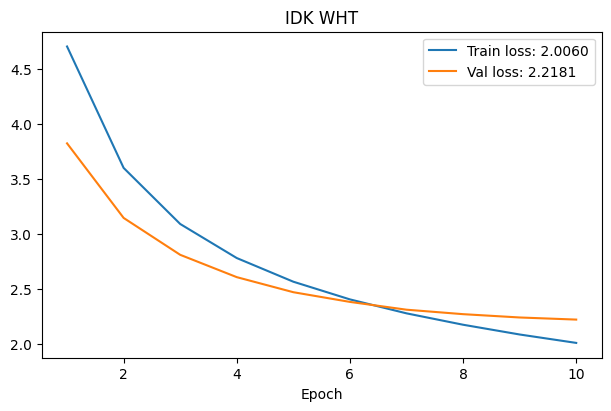

In [131]:
trainer_1.fit(model_1, train_data1, val_data1, 10, '../checkpoints/2nd_person_3am')

In [135]:
predicter_1 = PredictionModuleRef(tokenizer_eng1, tokenizer_pol1, encoder_eng1, encoder_pol1, model_1, alpha=0.6, max_seq=31)

In [159]:
predicter_1.translate_snt("You are in charge of many people.", 'p')

'Jesteście odpowiedzialny za wielu ludzi.'

In [161]:
with open("../local_data/model_reference/tokenizer_eng_1st.pkl", 'wb') as f:
    pickle.dump(tokenizer_eng1, f)

with open("../local_data/model_reference/tokenizer_pol_1st.pkl", 'wb') as f:
    pickle.dump(tokenizer_pol1, f)

with open("../local_data/model_reference/encoder_eng_1st", 'wb') as f:
    pickle.dump(encoder_eng1, f)

with open("../local_data/model_reference/encoder_pol_1st.pkl", 'wb') as f:
    pickle.dump(encoder_pol1, f)

In [133]:
import torch, re
import torch.nn.functional as F
from BPE_tokenizer import tokenize_eng

class PredictionModuleRef():
    def __init__(self, tokenizer_eng, tokenizer_pol, encoder_eng, encoder_pol, model, alpha=0.6, max_seq=36):
        self.model, self.device, self.num_blks = model, model.device, model.decoder.num_blks
        self.alpha, self.max_len, self.vocab_size = alpha, max_seq, tokenizer_pol.vocab_size
        self.encode_eng = encoder_eng.encode_snt
        self.bos_id = tokenizer_pol.vocab['<bos>']
        self.self_vocab = {'f': tokenizer_pol.vocab['<tgt_f>'],
                           'm': tokenizer_pol.vocab['<tgt_m>'],
                           'p': tokenizer_pol.vocab['<tgt_p>'],
                           'na': tokenizer_pol.vocab['<tgt_na>']}
        self.blocked_ids = list(self.self_vocab.values()) + [self.bos_id]
        self.rev_pol = {v: k for k, v in encoder_pol.vocab_encoder.items()}
        self.eos_id = tokenizer_pol.vocab['<eos>']

    def get_enc_input(self, eng_ids):
        X_enc = torch.tensor(eng_ids, device=self.device).view(1, -1)
        return X_enc, torch.tensor(X_enc.size(1), device=self.device).view(-1, 1)

    def translate_ids(self, eng_ids, pol_ids, num_k=5):
        init_seq = torch.tensor(pol_ids[:2], device=self.device).view(1, -1)
        pred_pol = self.predict_ids(*self.get_enc_input(eng_ids), init_seq, num_k)
        return pol_ids[:2] + pred_pol

    def translate_snt(self, eng_snt, gender='na', num_k=5):
        init_seq = torch.tensor([self.self_vocab[gender], self.bos_id], device=self.device).view(1, -1)
        pred_pol = self.predict_ids(*self.get_enc_input(self.encode_eng(tokenize_eng(eng_snt))+[2]), init_seq, num_k)
        return self.out_handler([self.rev_pol[x] for x in pred_pol][:-1])

    def out_handler(self, out_split):
        out_proc = " ".join(out_split).capitalize()
        out_proc = re.sub(r"([^_])\s+", r"\1", out_proc).replace('_', '')
        return re.sub(r'\s+([,.!?:])', r'\1', out_proc)

    def predict_ids(self, X_enc, valid_len, init_seq, num_k):
        with torch.inference_mode():
            self.model.eval()

            X_dec = self.model.encoder(X_enc, valid_len)
            dec_state = self.model.decoder.init_state(X_dec, valid_len)
            Y_dec, dec_state = self.model.decoder(init_seq, dec_state)

            cache_len = dec_state[2][0].shape[1]

            Y_log = F.log_softmax(Y_dec[:, -1:, :], dim=2)
            Y_log[..., self.blocked_ids] = float('-inf')
            vals_1, idxs_1 = torch.topk(Y_log, k=num_k, dim=2)

            dec_state = [
                X_dec.expand(num_k, valid_len.item(), -1),
                valid_len.expand(num_k, -1),
                [dec_state[2][i].expand(num_k, cache_len, -1) for i in range(self.num_blks)]
            ]

            logs_tens, seqs_tens = vals_1.view(num_k, 1), idxs_1.view(num_k, 1)
            logs_list, seqs_list = logs_tens.tolist(), seqs_tens.tolist()
            finished_seqs = []

            for _ in range(self.max_len - 2):
                Y_dec, dec_state = self.model.decoder(seqs_tens[:, -1:], dec_state)
                Y_log = F.log_softmax(Y_dec, dim=2).view(num_k, -1)
                Y_log[:, self.blocked_ids] = float('-inf')
                Y_log = Y_log + logs_tens

                vals_2, idxs_2 = torch.topk(Y_log.view(-1), k=2 * num_k)
                new_seqs, new_logs, par_idxs = [], [], []

                for tup in zip(idxs_2 // self.vocab_size, idxs_2 % self.vocab_size, vals_2):
                    par, tok, val = map(torch.Tensor.item, tup)
                    if tok == self.eos_id:
                        full_seq = seqs_list[par] + [tok]
                        finished_seqs.append((full_seq, val, len(full_seq)))
                    else:
                        new_seqs.append(seqs_list[par] + [tok])
                        new_logs.append([val])
                        par_idxs.append(par)

                    if len(new_seqs) == num_k:
                        break

                if not new_seqs or len(finished_seqs) >= num_k:
                    break

                dec_state[2] = [dec_state[2][i][par_idxs] for i in range(self.num_blks)]
                logs_list, seqs_list = new_logs, new_seqs
                logs_tens = torch.tensor(logs_list, device=self.device)
                seqs_tens = torch.tensor(seqs_list, device=self.device)

        if not finished_seqs:
            finished_seqs = [(seqs_list[i]+[2], logs_list[i][0], len(seqs_list[i])+1) for i in range(num_k)]
        best_seq = max(finished_seqs, key=lambda h: h[1] / (h[2] ** self.alpha))[0]
        return best_seq